In [1]:
# Imports para manipulação de dados
import numpy as np
import pandas as pd

# Imports para visualização de dados
import matplotlib.pyplot as plt
import matplotlib as m
import seaborn as sns

# Imports para análise de dados
import scipy
from scipy.stats import boxcox
import statsmodels
from statsmodels.tsa.stattools import adfuller

In [2]:
# Formatação para os gráficos e tabelas
plt.style.use('ggplot')
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [3]:
# Formatando os labels dos gráficos
m.rcParams['axes.labelsize'] = 14
m.rcParams['xtick.labelsize'] = 12
m.rcParams['ytick.labelsize'] = 12
m.rcParams['text.color'] = 'k'

In [4]:
# Versão da Linguagem Python
from platform import python_version
%reload_ext watermark
%watermark -a "Ricardo de Souza Silva" 

Author: Ricardo de Souza Silva



In [5]:
# Lista para identificar os valores ausentes
lista_labels_valores_ausentes = ["n/a,", "na", "undefined"]

In [6]:
# Lê um arquivo CSV ('dados_2012_2022.csv') e cria um DataFrame chamado 'dataset'
# Permite especificar valores a serem tratados como ausentes durante a leitura
dataset = pd.read_excel('exemplo1.xlsx', na_values = lista_labels_valores_ausentes)

In [8]:
dataset.head()

,MES,DIA,TOTAL_OCORRENCIAS
0,2012-01,2012-01-01,65
1,2012-01,2012-01-02,72
2,2012-01,2012-01-03,89
3,2012-01,2012-01-04,93
4,2012-01,2012-01-05,110


In [15]:
novodataset = dataset.groupby('MES')['TOTAL_OCORRENCIAS'].sum().reset_index()
novodataset.head()

,MES,TOTAL_OCORRENCIAS
0,2012-01,3961
1,2012-02,4127
2,2012-03,4869
3,2012-04,4617
4,2012-05,4706


In [17]:
novodataset.shape

(132, 2)

In [18]:
novodataset.describe().T

,count,mean,std,min,25%,50%,75%,max
TOTAL_OCORRENCIAS,132.0,2954.371212,1252.14466,943.0,1812.5,3030.5,3967.5,5638.0


In [21]:
# =====================================================================
# EXIBIÇÃO DO PERÍODO COBERTO PELA SÉRIE TEMPORAL
# =====================================================================

# Exibe no console a data inicial e a data final presentes
# na coluna 'mes' do DataFrame.
#
# dados.mes.min() -> retorna a menor data (início da série).
# dados.mes.max() -> retorna a maior data (fim da série).
#
# O método format() substitui os {} pelos valores retornados,
# organizando a mensagem de forma legível.
#
# '\n' insere uma quebra de linha entre as duas informações.
print(
    'Início do Período de Tempo: {}\nFinal do Período de Tempo: {}'.format(
        novodataset['MES'].min(),
        novodataset['MES'].max()
    )
)

Início do Período de Tempo: 2012-01
Final do Período de Tempo: 2022-12


In [23]:
# =====================================================================
# CONVERSÃO DA COLUNA 'mes' PARA O TIPO DATETIME
# =====================================================================

# Converte a coluna 'mes', que está armazenada como texto (string),
# para o tipo datetime do Pandas.
#
# Isso permite realizar operações envolvendo datas, como:
# - Filtrar períodos específicos;
# - Ordenar cronologicamente;
# - Criar gráficos de séries temporais;
# - Extrair ano, mês, trimestre, etc.;
# - Aplicar modelos de séries temporais.
#
# O parâmetro format='%Y-%m' informa que as datas estão no formato:
# %Y -> ano com quatro dígitos (ex.: 2024)
# %m -> mês com dois dígitos (ex.: 07)
#
# Exemplo:
# "2024-07" → Timestamp('2024-07-01 00:00:00')
novodataset['MES'] = pd.to_datetime(novodataset['MES'], format='%Y-%m')

In [25]:
novodataset.dtypes

MES                  datetime64[ns]
TOTAL_OCORRENCIAS             int64
dtype: object

In [26]:
# Vamos transformar a coluna de data no índice do conjunto de dados. 
# Isso vai facilitar nosso trabalho mais a frente.
# =====================================================================
# DEFINIÇÃO DA COLUNA DE DATA COMO ÍNDICE DO DATAFRAME
# =====================================================================

# Cria um novo DataFrame chamado 'dados_serie', utilizando a coluna
# 'mes' como índice (index) da tabela.
#
# Em séries temporais, é uma prática recomendada utilizar a coluna de
# datas como índice, pois diversas funções do Pandas e do Statsmodels
# esperam que o índice seja composto por datas.
#
# O DataFrame original ('dados') permanece inalterado, pois o resultado
# é armazenado em uma nova variável.
dados_serie = novodataset.set_index('MES')

In [27]:
# Visualizando os Dados
dados_serie.head()

,TOTAL_OCORRENCIAS
MES,
2012-01-01,3961
2012-02-01,4127
2012-03-01,4869
2012-04-01,4617
2012-05-01,4706


In [28]:
# Visualizando o índice
dados_serie.index

DatetimeIndex(['2012-01-01', '2012-02-01', '2012-03-01', '2012-04-01', '2012-05-01', '2012-06-01', '2012-07-01', '2012-08-01', '2012-09-01', '2012-10-01',
               ...
               '2022-03-01', '2022-04-01', '2022-05-01', '2022-06-01', '2022-07-01', '2022-08-01', '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01'], dtype='datetime64[ns]', name='MES', length=132, freq=None)

In [29]:
# Será que algum valor nulo está presente nos dados?
dados_serie.isnull().sum()

TOTAL_OCORRENCIAS    0
dtype: int64

In [30]:
type(dados_serie)

pandas.core.frame.DataFrame

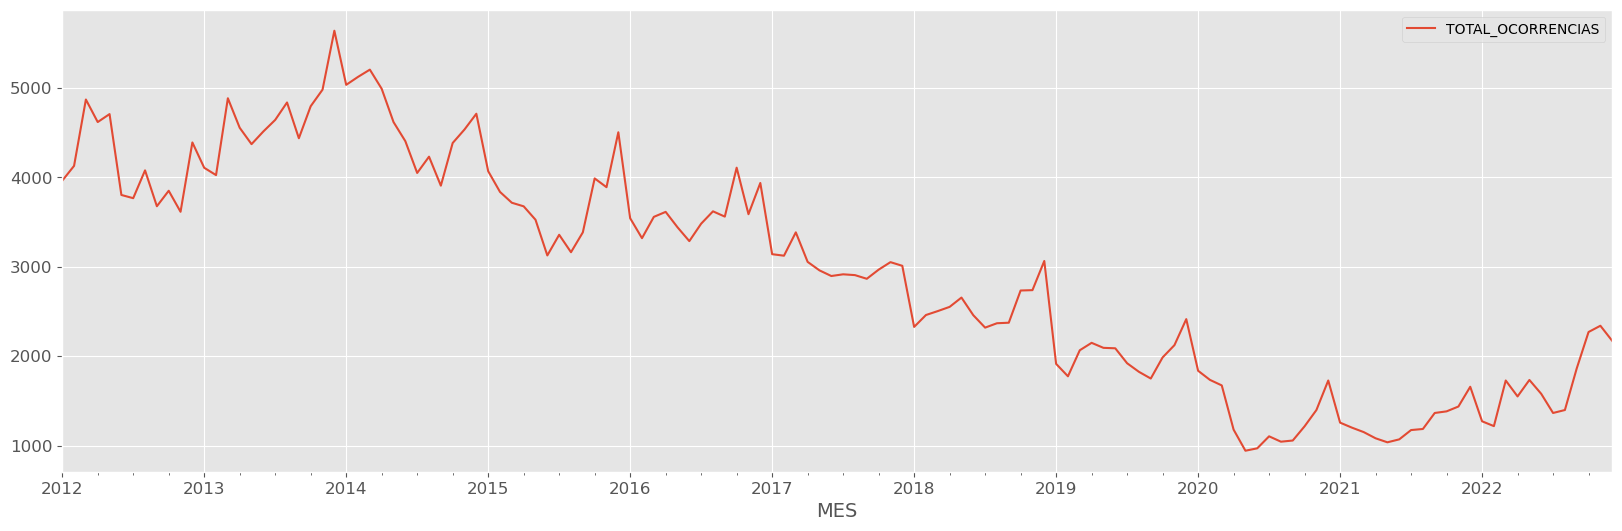

In [32]:
# Plot da Série Temporal - aqui já observamos algumas tendências
# =====================================================================
# PLOTAGEM DA SÉRIE TEMPORAL
# =====================================================================

# Cria um gráfico de linha utilizando os dados do DataFrame
# 'dados_serie'.
#
# Como o índice do DataFrame é composto por datas ('mes'),
# o eixo X será preenchido automaticamente com o período da série,
# enquanto o eixo Y exibirá os valores da variável
# 'usuarios_ativos'.
#
# O parâmetro figsize=(15, 6) define o tamanho da figura:
# 15 polegadas de largura por 6 polegadas de altura,
# proporcionando melhor visualização da série temporal.
dados_serie.plot(figsize=(20, 6))

# Exibe o gráfico na tela.
# Embora em notebooks (como Jupyter) muitas vezes o gráfico seja
# mostrado automaticamente, o plt.show() garante que a figura
# seja renderizada corretamente em qualquer ambiente.
plt.show()

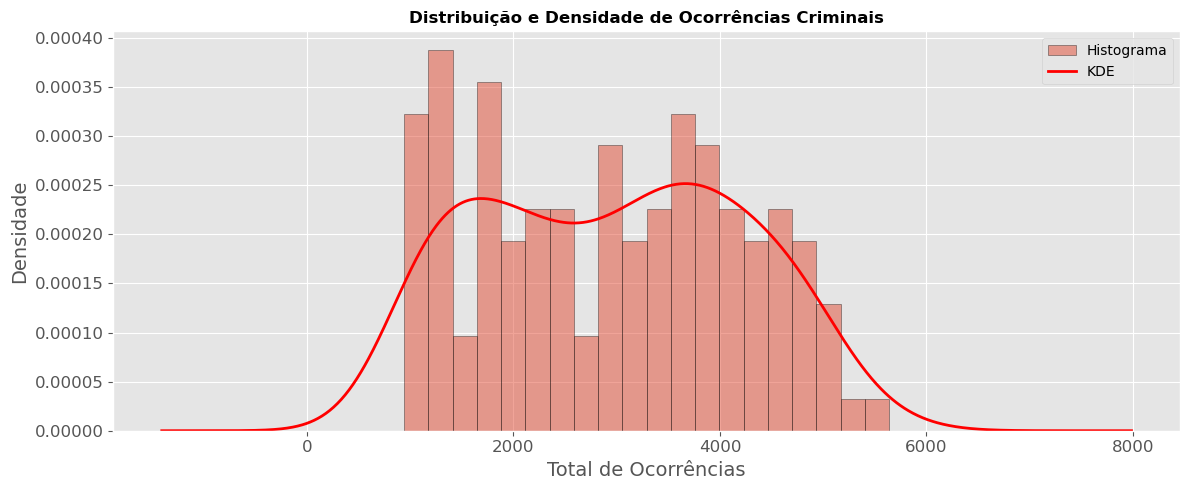

In [ ]:
# Cria uma nova figura (janela do gráfico)
# figsize=(12, 5) define o tamanho da figura:
# 12 = largura em polegadas
# 5 = altura em polegadas
plt.figure(figsize=(12, 5))


# HISTOGRAMA

# Seleciona a coluna TOTAL_OCORRENCIAS do DataFrame
# e cria um histograma.
dados_serie['TOTAL_OCORRENCIAS'].plot(
    # Tipo de gráfico
    kind='hist',
    # Normaliza o histograma para que a área total seja igual a 1.
    # Isso permite comparar o histograma com a curva KDE.
    density=True,
    # Divide os dados em 20 intervalos (bins).
    # Quanto maior o número de bins,
    # mais detalhado será o histograma.
    bins=20,
    # Define a transparência das barras.
    # alpha varia de 0 (totalmente transparente)
    # até 1 (totalmente opaco).
    alpha=0.5,
    # Cor da borda das barras
    edgecolor='black',
    # Nome que aparecerá na legenda
    label='Histograma'
)

# CURVA KDE (Kernel Density Estimation)
# Cria uma estimativa contínua da distribuição dos dados.
# É uma curva suavizada que representa a densidade
# de probabilidade da variável.
dados_serie['TOTAL_OCORRENCIAS'].plot(

    # Tipo de gráfico
    kind='kde',
    # Cor da curva
    color='red',
    # Espessura da linha
    linewidth=2,
    # Texto da legenda
    label='KDE'
)

# TÍTULO
# Define o título do gráfico.
plt.title(
    'Distribuição e Densidade de Ocorrências Criminais',
    # Tamanho da fonte
    fontsize=12,
    # Peso da fonte (negrito)
    fontweight='bold'
)

# RÓTULO DO EIXO X
# Nome do eixo horizontal.
plt.xlabel('Total de Ocorrências')

# RÓTULO DO EIXO Y
# Como o histograma foi normalizado (density=True),
# o eixo Y representa densidade e não quantidade.
plt.ylabel('Densidade')

# LEGENDA
# Exibe a legenda contendo:
# - Histograma
# - KDE
plt.legend()

# AJUSTE AUTOMÁTICO DO LAYOUT
# Ajusta automaticamente os espaços entre os elementos
# do gráfico para evitar sobreposição.
plt.tight_layout()

# EXIBE O GRÁFICO
plt.show()